# Task 5 — Strategy Backtesting

Backtest the Task 4 optimized portfolio against a static 60% SPY / 40% BND benchmark over the most recent 12-month holdout window (2025-01-01 onward).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

from src import data_loader, eda, arima_model, lstm_model, portfolio, backtest


In [2]:
import json
raw = data_loader.fetch_asset_data(cache_dir='../data/raw')
cleaned = data_loader.clean_asset_data(raw)
prices = data_loader.combine_asset_data(cleaned, field='Adj Close')
returns = data_loader.compute_daily_returns(prices)
recommendation = json.load(open('../data/processed/task4_portfolio_recommendation.json'))
strategy_weights = recommendation['recommended_weights']
strategy_weights

2026-07-04 07:47:33,377 [INFO] Loading cached data for TSLA from ../data/raw/TSLA.csv


2026-07-04 07:47:33,419 [INFO] Loading cached data for BND from ../data/raw/BND.csv


2026-07-04 07:47:33,439 [INFO] Loading cached data for SPY from ../data/raw/SPY.csv


2026-07-04 07:47:33,489 [INFO] TSLA: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:47:33,495 [INFO] BND: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:47:33,504 [INFO] SPY: reindexed to 2997 business days, filled 109 missing trading days


{'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0}

## 5.1 Simulate strategy vs. benchmark (monthly rebalanced)

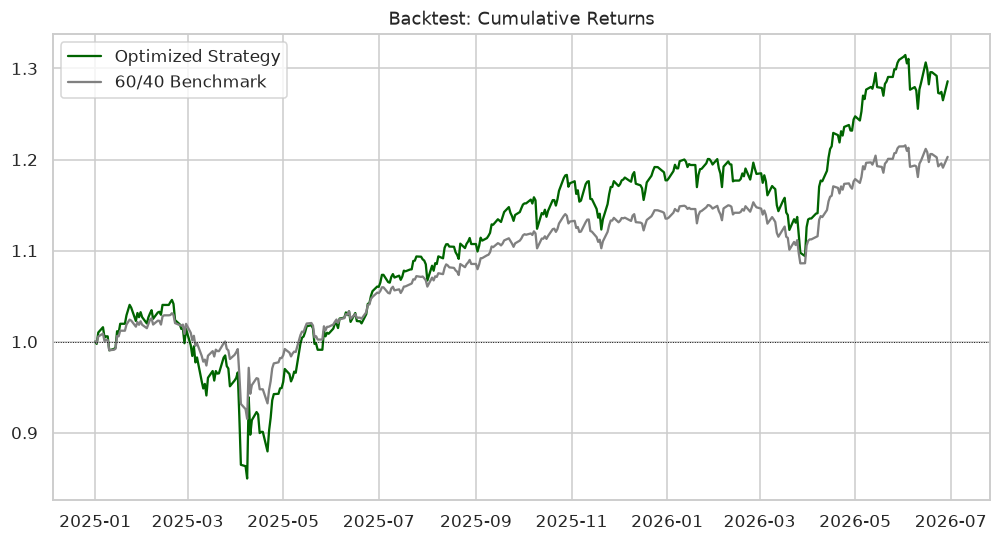

In [3]:
backtest_returns = returns['2025-01-01':]
benchmark_weights = {'SPY': 0.6, 'BND': 0.4, 'TSLA': 0.0}
strategy_returns = backtest.simulate_fixed_weights(backtest_returns, strategy_weights, rebalance=True)
benchmark_returns = backtest.simulate_fixed_weights(backtest_returns, benchmark_weights, rebalance=True)
strategy_cum = (1 + strategy_returns).cumprod()
benchmark_cum = (1 + benchmark_returns).cumprod()
fig, ax = plt.subplots(figsize=(11,5.5))
ax.plot(strategy_cum.index, strategy_cum.values, label='Optimized Strategy', color='darkgreen')
ax.plot(benchmark_cum.index, benchmark_cum.values, label='60/40 Benchmark', color='gray')
ax.axhline(1.0, color='black', linewidth=0.6, linestyle=':')
ax.legend(); ax.set_title('Backtest: Cumulative Returns'); plt.show()

## 5.2 Performance metrics

In [4]:
strategy_metrics = backtest.performance_metrics(strategy_returns)
benchmark_metrics = backtest.performance_metrics(benchmark_returns)
metrics_df = pd.DataFrame([strategy_metrics, benchmark_metrics], index=['Strategy', 'Benchmark (60/40)'])
metrics_df.round(3)

,total_return_pct,annualized_return_pct,sharpe_ratio,max_drawdown_pct
Strategy,28.598,17.696,0.904,-18.755
Benchmark (60/40),20.293,12.715,0.978,-11.248


## 5.3 Conclusion

Compare total return, annualized return, Sharpe ratio, and max drawdown between the two approaches (see table above). This determines whether the forecast-informed, MPT-optimized strategy outperformed the simple static benchmark over the backtest window, and at what cost in terms of volatility and drawdown risk.